# 2. Exploratory Data Analysis

**Purpose:** communicate cohort flow, missingness, univariate associations, correlation structure, and patient clustering.

**Key message:** cardiovascular variables carry the strongest univariate signal; thyroid variables show association but must be judged by incremental predictive value in later notebooks.

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
VENV_PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
PIPELINE_PY = VENV_PY if VENV_PY.exists() else Path(sys.executable)
FEATURE_SETS = [
    'CV17', 'CV17_THY26', 'CV17_BIN', 'CV17_ORD',
    'CV17_CONT', 'CV17_CAT', 'CV17_RATIO', 'CV17_RATIO_ONLY'
]

def read_csv(name, folder=DATA, **kwargs):
    path = folder / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def show_image(path, width=850):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

def run_step(step, force=False):
    cmd = [str(PIPELINE_PY), str(ROOT / 'run_pipeline.py'), '--step', step]
    if force:
        cmd.append('--force')
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

def pct(x):
    return f'{100*x:.1f}%'

## How to use this notebook

Use this notebook for descriptive discussion with the team. It shows both `strict` and `competing` where relevant, while the cohort flow remains based on the full merged cohort.

In [ ]:
RUN_PIPELINE_STEP = True
if RUN_PIPELINE_STEP:
    run_step('eda', force=False)
else:
    print('Using existing EDA artefacts. Set RUN_PIPELINE_STEP=True to regenerate with .venv.')

Using existing EDA artefacts. Set RUN_PIPELINE_STEP=True to regenerate with .venv.


In [3]:
full = read_csv('cohort_full.csv')
strict = read_csv('cohort_strict.csv')
competing = read_csv('cohort_competing.csv')
print(f'Loaded cohorts: full={len(full)}, strict={len(strict)}, competing={len(competing)}')

Loaded cohorts: full=8065, strict=4390, competing=5437


## 2.1 Cohort flow

This is the visual and tabular audit of who enters classification and who is censored/removed.

,node,n
0,Full cohort,8065
1,CVD death <=7y,843
2,Event-free >=7y,3547
3,Alive FU <7y,2628
4,Non-CVD death <7y,1047
5,Strict cohort,4390
6,Competing cohort,5437


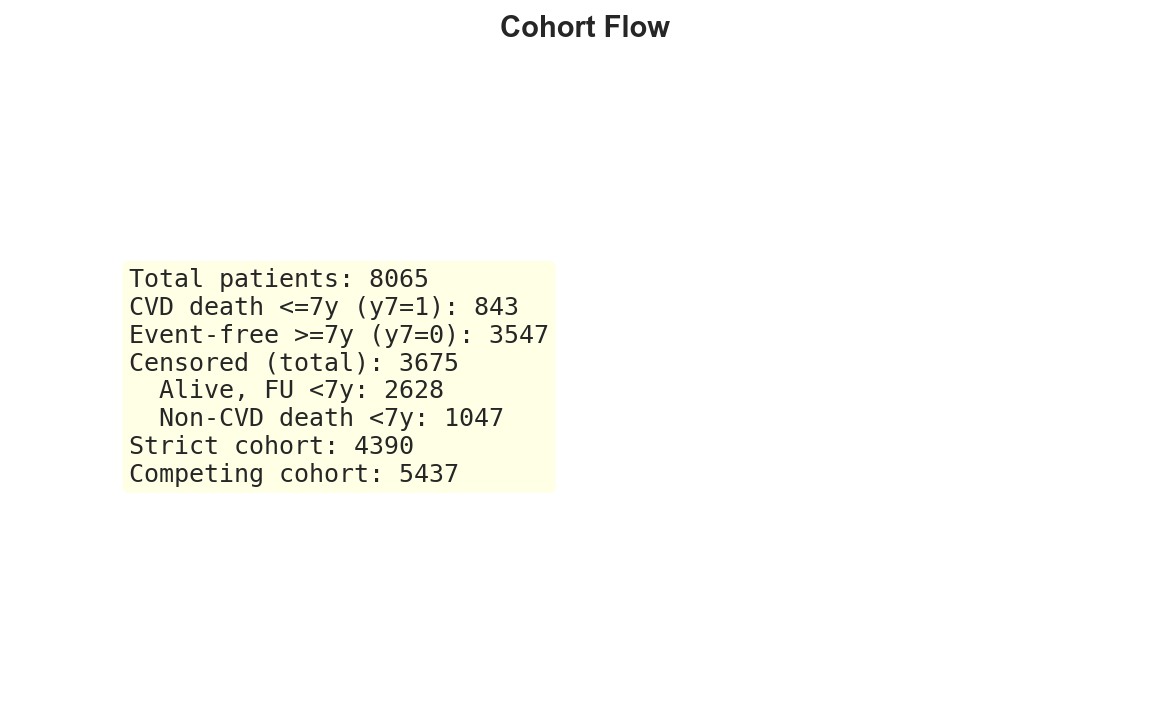

In [4]:
HORIZON_DAYS = 7 * 365.25
cvd_within = (full['event_cvd'].eq(1) & full['time_days'].le(HORIZON_DAYS))
event_free = (full['time_days'].ge(HORIZON_DAYS) & ~cvd_within)
noncvd_early = (full['event_noncvd'].eq(1) & full['time_days'].lt(HORIZON_DAYS))
alive_short = (full['event_death'].eq(0) & full['time_days'].lt(HORIZON_DAYS))
flow = pd.DataFrame([
    {'node': 'Full cohort', 'n': len(full)},
    {'node': 'CVD death <=7y', 'n': int(cvd_within.sum())},
    {'node': 'Event-free >=7y', 'n': int(event_free.sum())},
    {'node': 'Alive FU <7y', 'n': int(alive_short.sum())},
    {'node': 'Non-CVD death <7y', 'n': int(noncvd_early.sum())},
    {'node': 'Strict cohort', 'n': len(strict)},
    {'node': 'Competing cohort', 'n': len(competing)},
])
display(flow)
show_image(FIGURES / 'cohort_flow.png', width=650)

## 2.2 Missingness

There should be no missing values in the 26 main modelling features.

In [5]:
from configs.config import CARDIO_17, THYROID_RAW9
features = CARDIO_17 + THYROID_RAW9
rows = []
for name, df in [('strict', strict), ('competing', competing)]:
    miss = df[features].isna().sum()
    rows.append({'cohort': name, 'missing_total': int(miss.sum()), 'max_missing_feature': miss.idxmax(), 'max_missing': int(miss.max())})
display(pd.DataFrame(rows))

,cohort,missing_total,max_missing_feature,max_missing
0,strict,0,Gender,0
1,competing,0,Gender,0


## 2.3 Univariate associations

Interpretation note: odds ratios and rank-biserial effects are not on the same scale; use this table to identify signal, not to claim incremental value.

In [6]:
path = REPORTS / 'univariate_association.csv'
if path.exists():
    univ = pd.read_csv(path)
    if 'cohort' not in univ.columns:
        univ.insert(0, 'cohort', 'strict_legacy')
    display(univ.sort_values(['cohort', 'effect_size'], ascending=[True, False]).groupby('cohort').head(12))
else:
    print('Run EDA first.')

,cohort,feature,type,test,statistic,p_value,effect_size,effect_name
0,strict_legacy,PostIsch_DCM,binary,chi2,331.879744,3.744382e-74,5.977702,OR
1,strict_legacy,Previous_CABG,binary,chi2,69.367504,8.172411e-17,2.569680,OR
2,strict_legacy,Acute_MI,binary,chi2,58.114996,2.472344e-14,2.510171,OR
3,strict_legacy,Diabetes,binary,chi2,96.181011,1.048457e-22,2.271337,OR
4,strict_legacy,AFib,binary,chi2,87.066124,1.049529e-20,2.246187,OR
5,strict_legacy,SCH,binary,chi2,21.148067,4.251298e-06,1.911822,OR
6,strict_legacy,Previous_MI,binary,chi2,64.743286,8.531985e-16,1.904216,OR
7,strict_legacy,Low_T3,binary,chi2,36.317368,1.676630e-09,1.696006,OR
8,strict_legacy,Hypothyroid,binary,chi2,3.251101,7.137551e-02,1.652541,OR
9,strict_legacy,Hyperthyroid,binary,chi2,3.488325,6.180309e-02,1.620559,OR


## 2.4 Distributions, correlations, and clustering

The plots below are the communication artefacts: continuous feature distributions by class, feature correlation/correlation clusters, and patient PCA/clustering.

### Cohort: strict

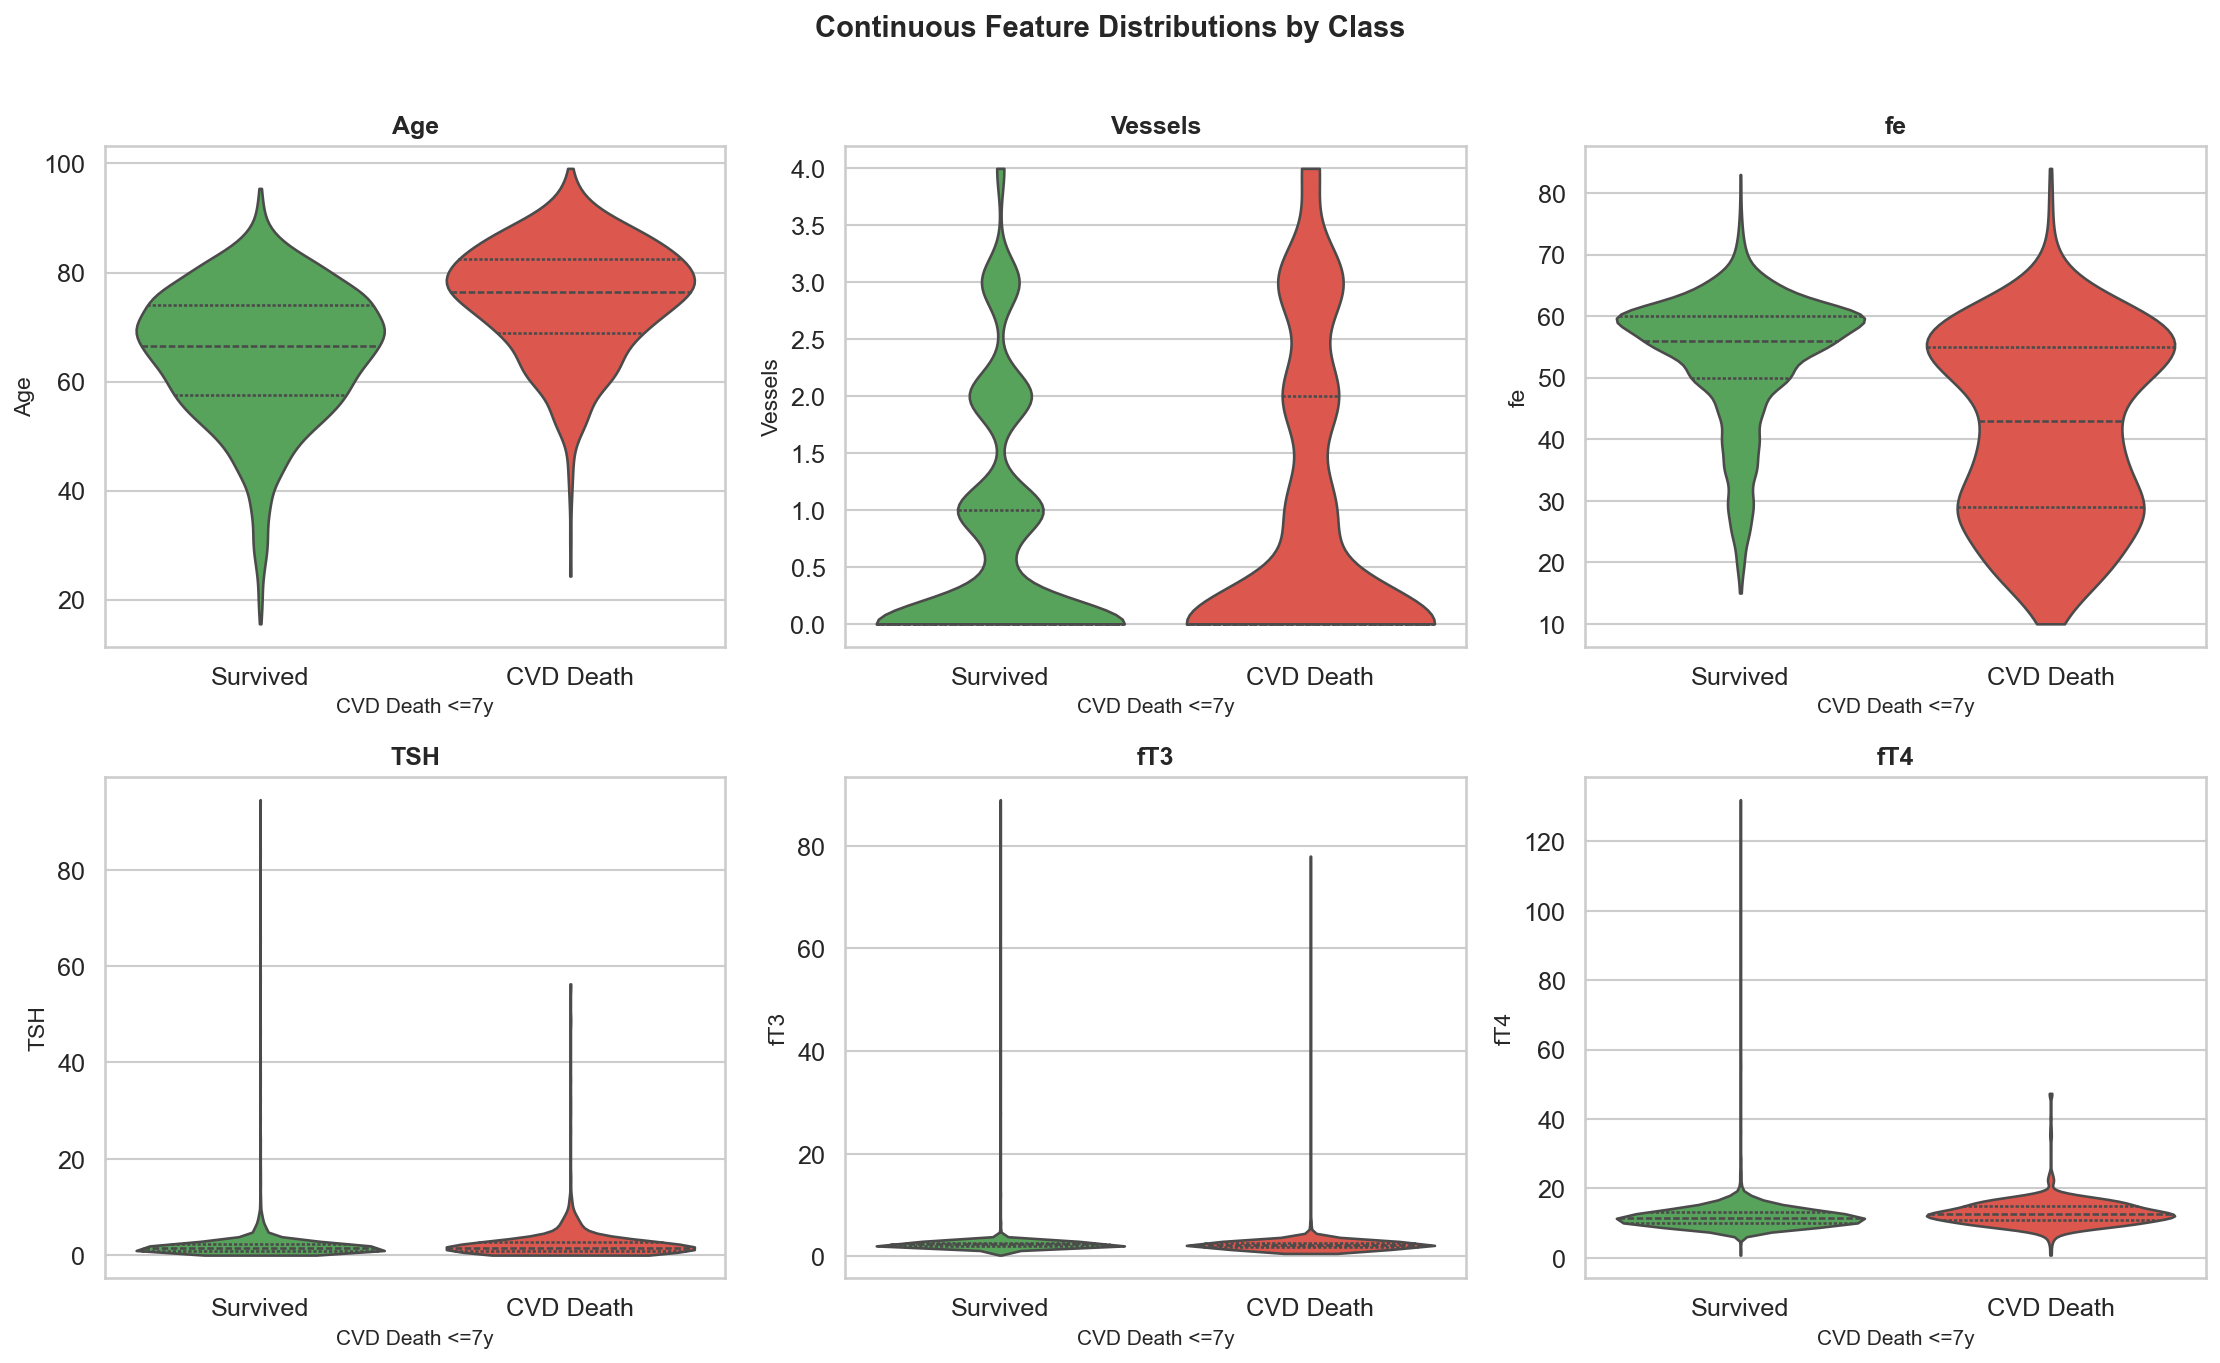

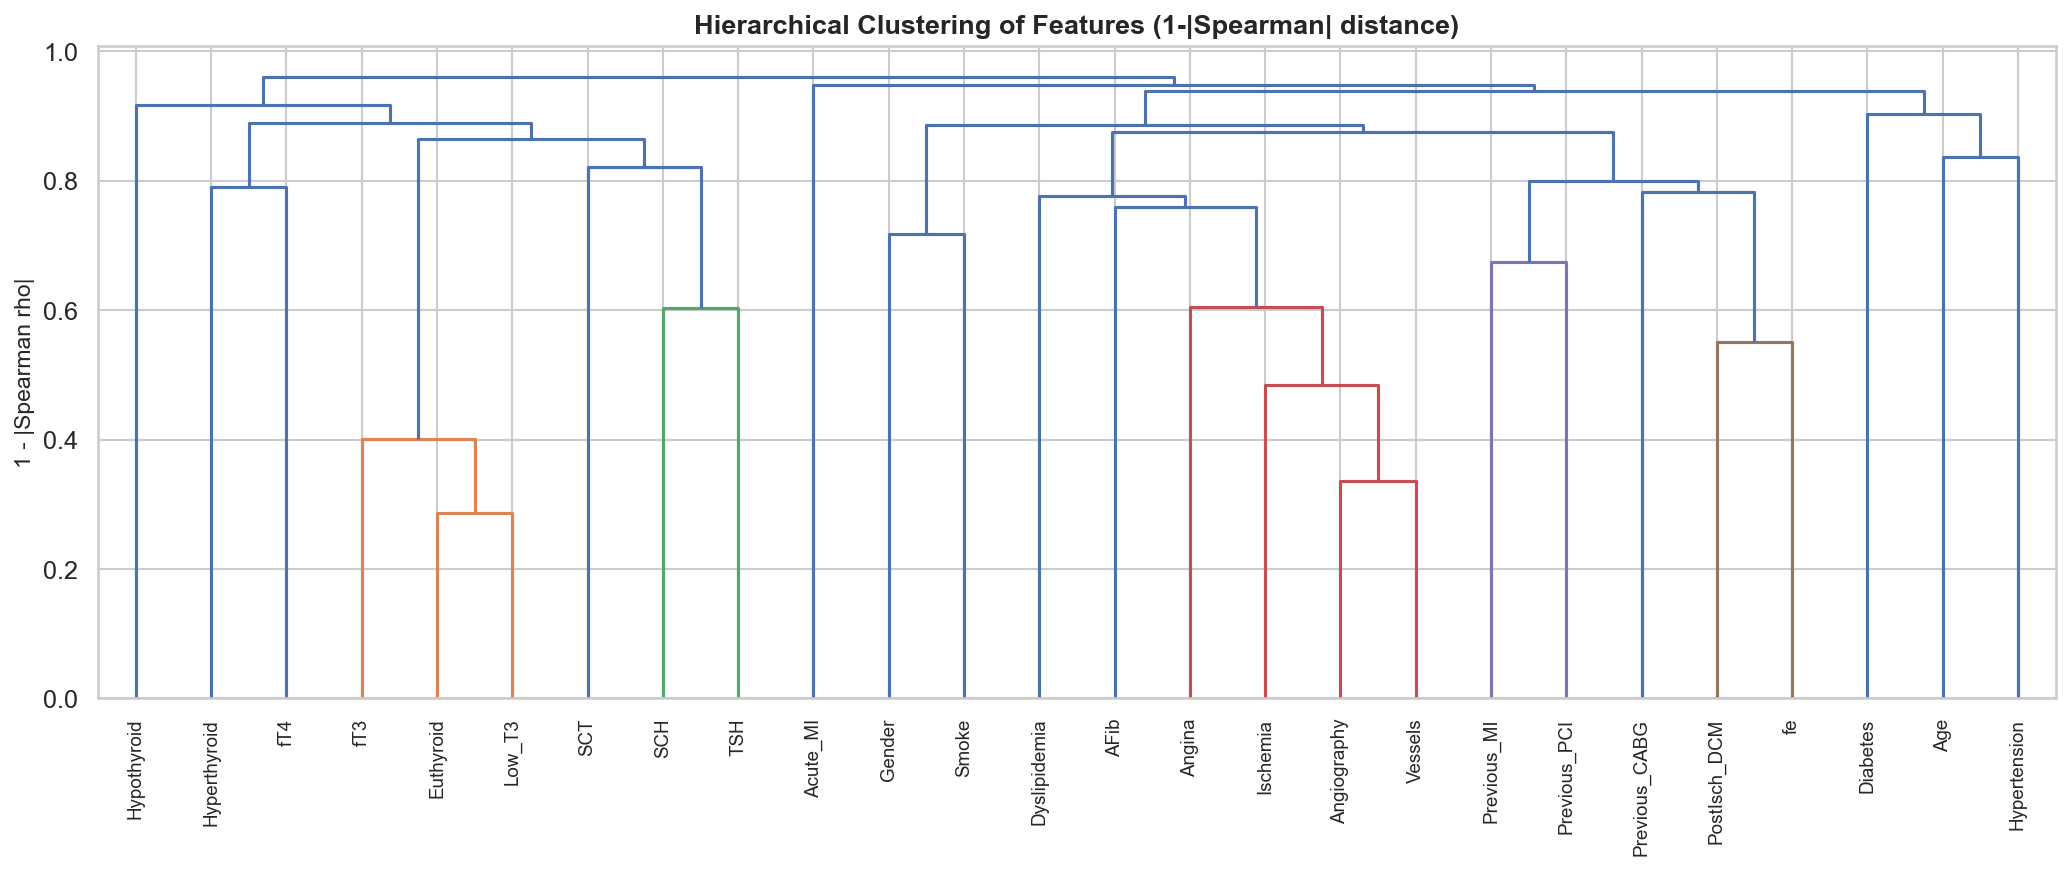

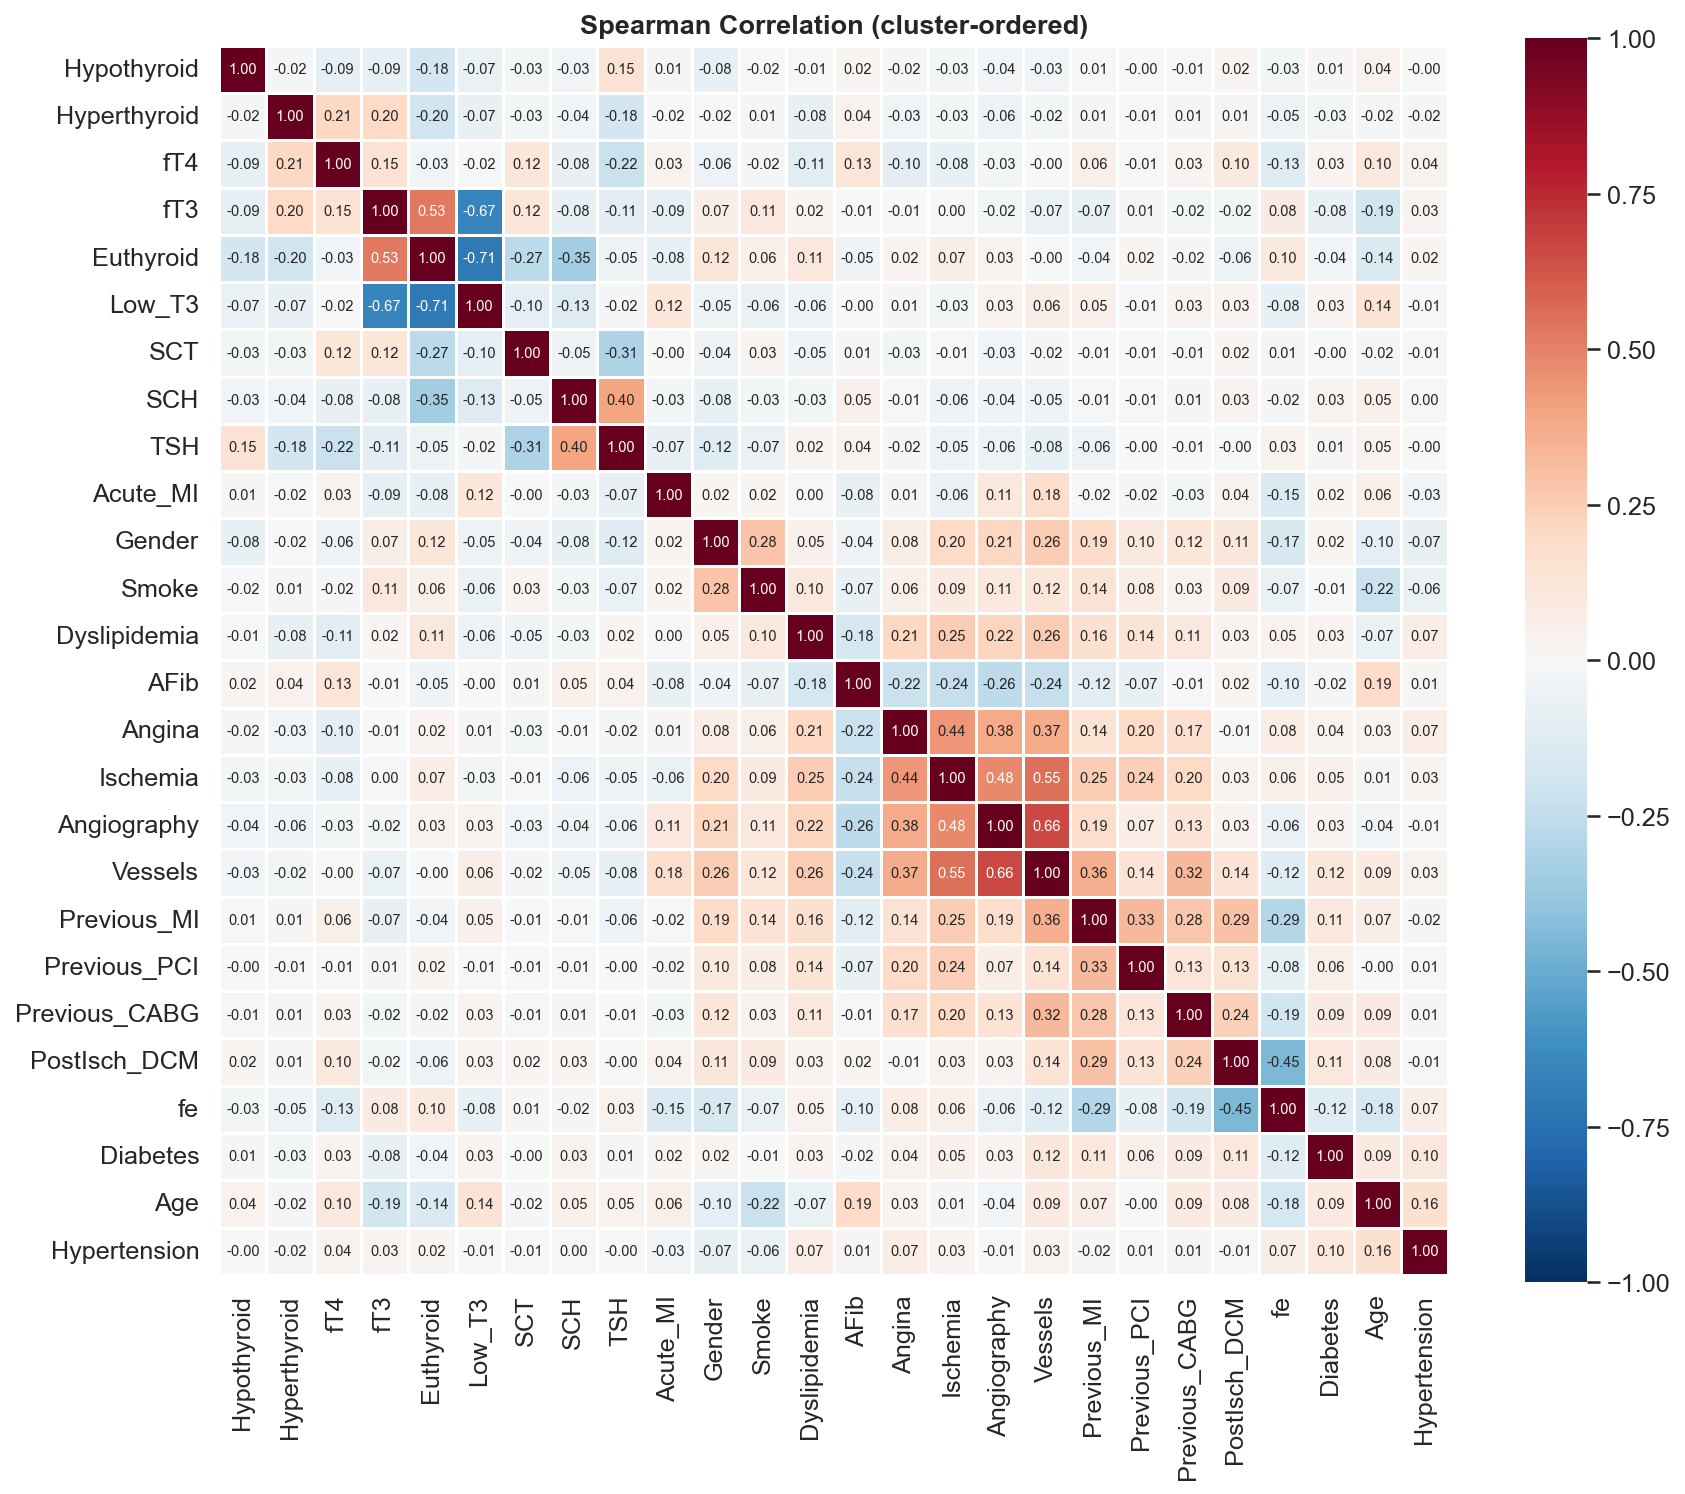

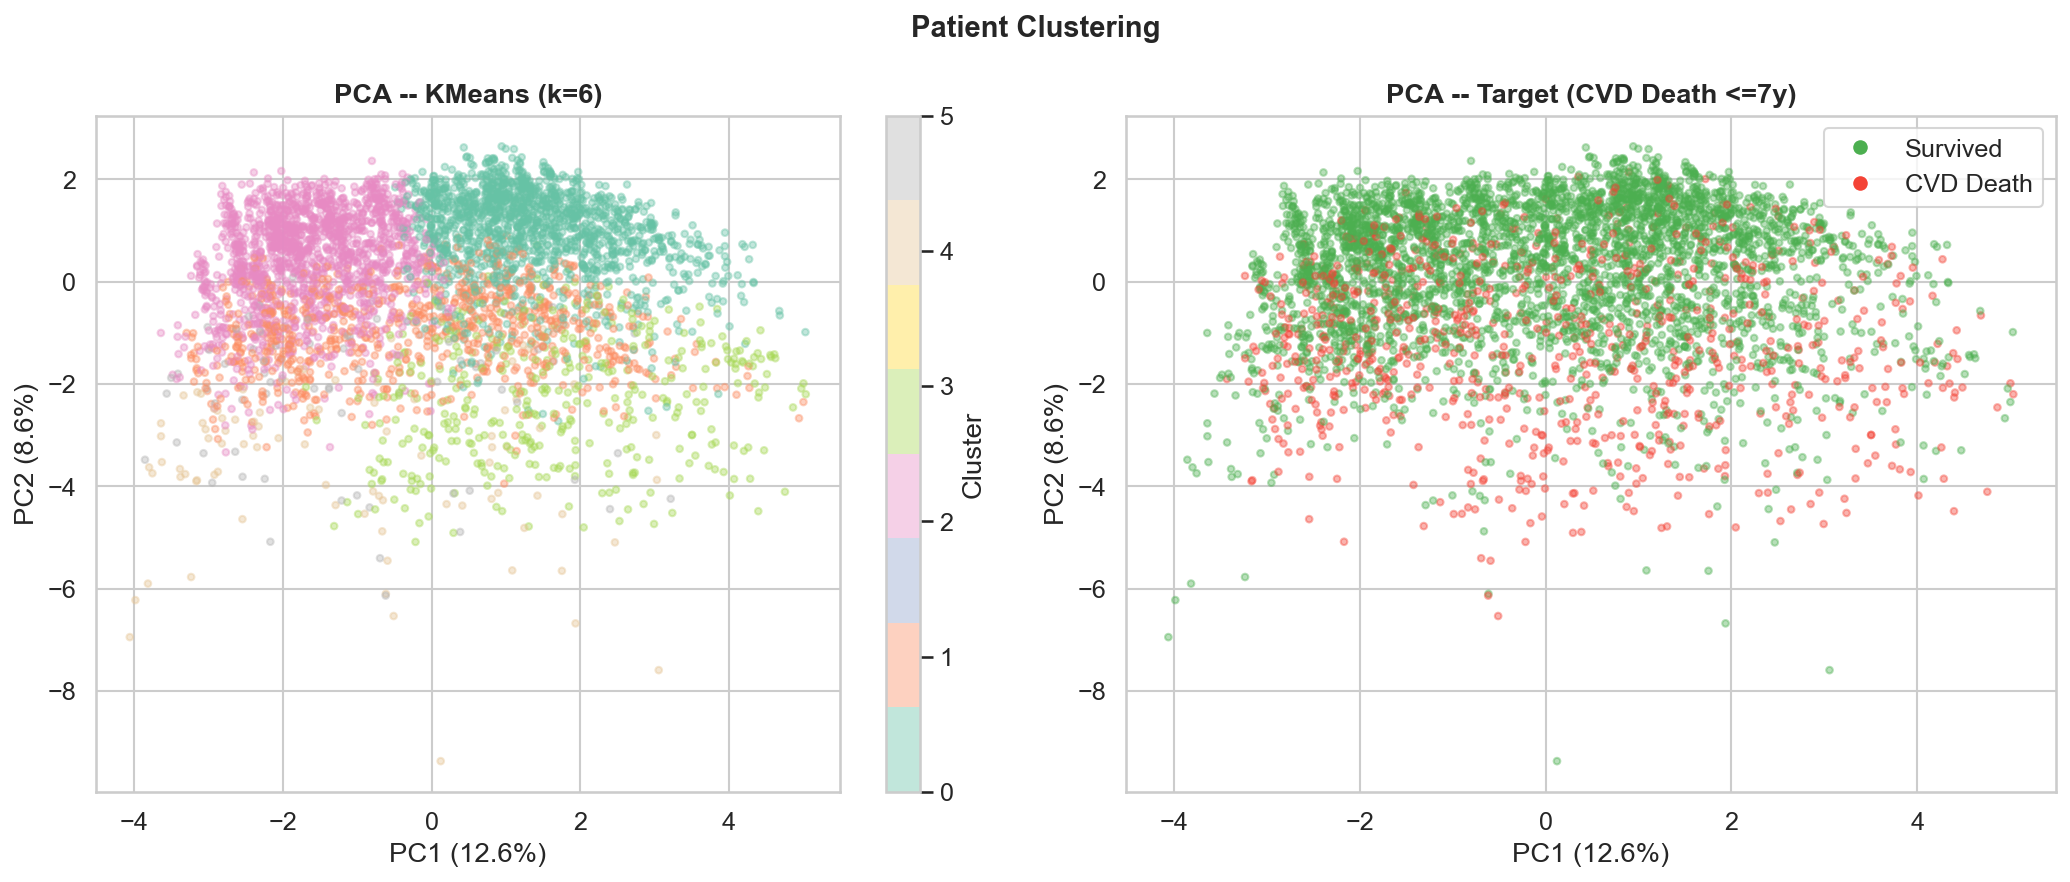

### Cohort: competing

Missing figure: c:\Users\ileni\ml4cad\reports\figures\violins_continuous_competing.png
Missing figure: c:\Users\ileni\ml4cad\reports\figures\dendrogram_features_competing.png
Missing figure: c:\Users\ileni\ml4cad\reports\figures\heatmap_spearman_competing.png
Missing figure: c:\Users\ileni\ml4cad\reports\figures\pca_clustering_competing.png


In [7]:
for cohort in ['strict', 'competing']:
    display(Markdown(f'### Cohort: {cohort}'))
    for stem, legacy in [
        ('violins_continuous', cohort == 'strict'),
        ('dendrogram_features', cohort == 'strict'),
        ('heatmap_spearman', cohort == 'strict'),
        ('pca_clustering', cohort == 'strict'),
    ]:
        path = FIGURES / f'{stem}_{cohort}.png'
        if not path.exists() and legacy:
            path = FIGURES / f'{stem}.png'
        show_image(path, width=850)

## Take-home message

- No relevant feature missingness issue is visible in the modelling feature set.
- The strongest univariate associations are cardiovascular.
- Thyroid variables are associated, especially `SCH`/`Low_T3`, but later model comparisons determine whether they add predictive value.